<a href="https://colab.research.google.com/github/Asandandlela16/Africa-Economic-Banking-and-Systemic-Crisis-from-1860-to-2014/blob/main/Africa_Economic%2C_Banking_and_Systemic_Crisis_from_1860_to_2014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import files
uploaded = files.upload()

Saving african_crises[1].csv to african_crises[1].csv


In [32]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [33]:
data = pd.read_csv('african_crises[1].csv')
data.head()

,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


Total Entries: 1059 entries, indexed from 0 to 1058.
Columns: There are 14 columns in total.
Non-Null Counts: All columns have 1059 non-null values, indicating that there are no missing values in any column.
Data Types:
float64: exch_usd, gdp_weighted_default, inflation_annual_cpi
int64: case, year, systemic_crisis, domestic_debt_in_default, sovereign_external_debt_default, independence, currency_crises, inflation_crises
object: cc3, country, banking_crisis
The dataset is quite clean in terms of missing values and ready for further analysis.

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

In [16]:
inflation_crisis_stats = data.groupby('systemic_crisis')['inflation_annual_cpi'].describe()
display(inflation_crisis_stats)

,count,mean,std,min,25%,50%,75%,max
systemic_crisis,,,,,,,,
0,977.0,19.412891,1.676822e+02,-28.502137,2.060865,5.549986,11.003204,4146.01
1,82.0,269024.520779,2.428271e+06,-7.670000,5.446750,11.707721,26.974000,21989695.22


### Descriptive Statistics:

During Non-Crisis Periods (systemic_crisis = 0): The mean annual inflation (inflation_annual_cpi) is approximately 19.41. The median is around 5.55, and the inflation generally ranges from -28.50 to 4146.01, with most values between 2.06 and 11.00 (25th to 75th percentile).
During Systemic Crisis Periods (systemic_crisis = 1): The mean annual inflation skyrockets to approximately 269,024.52. This is a dramatic increase compared to non-crisis periods. The median inflation is around 11.71, indicating that even typical crisis periods have higher inflation. However, the extremely high mean suggests the presence of severe hyperinflation events, as evidenced by the maximum value reaching over 21 million.



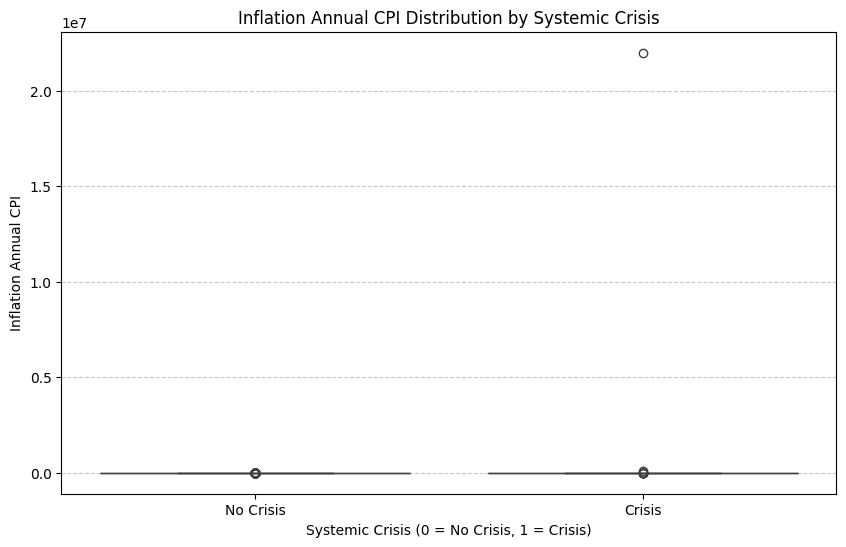

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='systemic_crisis', y='inflation_annual_cpi', data=data)
plt.title('Inflation Annual CPI Distribution by Systemic Crisis')
plt.xlabel('Systemic Crisis (0 = No Crisis, 1 = Crisis)')
plt.ylabel('Inflation Annual CPI')
plt.xticks([0, 1], ['No Crisis', 'Crisis'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Box Plot Interpretation:

The box plot visually reinforces these findings. You can observe that the box and whiskers for 'Systemic Crisis' (1) are significantly higher and more spread out than for 'No Crisis' (0).
The presence of many outlier points (individual dots) above the 'Systemic Crisis' box indicates instances of extreme inflation, often referred to as hyperinflation, which heavily influence the mean.
In summary, systemic crises are strongly associated with much higher and more volatile inflation rates, including periods of hyperinflation.

The descriptive statistics and the box plot should provide insights into how inflation behaves during systemic crises. We can observe differences in the mean, median, and spread of inflation between the two groups.

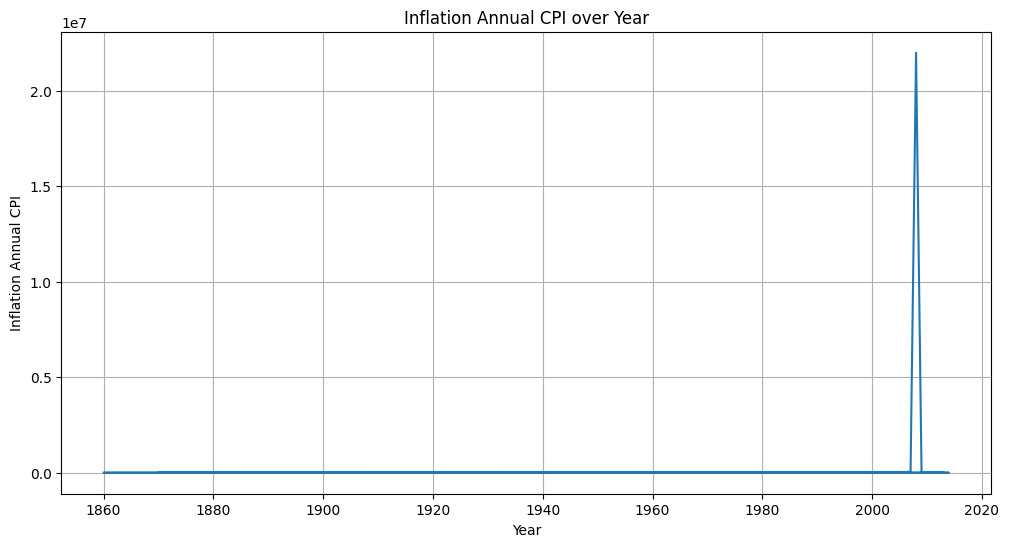

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data['year'], data['inflation_annual_cpi'])
plt.xlabel('Year')
plt.ylabel('Inflation Annual CPI')
plt.title('Inflation Annual CPI over Year')
plt.grid(True)
plt.show()

In [11]:
data.describe()

,case,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1.059000e+03,1059.000000,1059.000000,1059.000000
mean,35.613787,1967.767705,0.077432,43.140831,0.039660,0.152975,0.006402,2.084889e+04,0.776204,0.132200,0.129367
std,23.692402,33.530632,0.267401,111.475380,0.195251,0.360133,0.043572,6.757274e+05,0.416984,0.349847,0.335765
min,1.000000,1860.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.850214e+01,0.000000,0.000000,0.000000
25%,15.000000,1951.000000,0.000000,0.195350,0.000000,0.000000,0.000000,2.086162e+00,1.000000,0.000000,0.000000
50%,38.000000,1973.000000,0.000000,0.868400,0.000000,0.000000,0.000000,5.762330e+00,1.000000,0.000000,0.000000
75%,56.000000,1994.000000,0.000000,8.462750,0.000000,0.000000,0.000000,1.164405e+01,1.000000,0.000000,0.000000
max,70.000000,2014.000000,1.000000,744.306139,1.000000,1.000000,0.400000,2.198970e+07,1.000000,2.000000,1.000000


In [21]:
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()
display(corr)

,case,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises
case,1.000000,0.115574,0.010991,-0.231976,0.128358,-0.039262,-0.032981,0.044762,0.021858,0.095339,0.006405
year,0.115574,1.000000,0.197450,0.248757,0.136828,0.271890,-0.054670,0.037035,0.407360,0.189390,0.098630
systemic_crisis,0.010991,0.197450,1.000000,0.202687,0.122158,0.249850,0.005274,0.106452,0.147083,0.112751,0.172562
exch_usd,-0.231976,0.248757,0.202687,1.000000,0.005253,0.422890,-0.040726,-0.011947,0.126034,-0.056472,-0.063783
domestic_debt_in_default,0.128358,0.136828,0.122158,0.005253,1.000000,0.464751,-0.029874,0.151832,0.109120,0.227585,0.224429
sovereign_external_debt_default,-0.039262,0.271890,0.249850,0.422890,0.464751,1.000000,0.345919,0.072609,0.228192,0.199428,0.187930
gdp_weighted_default,-0.032981,-0.054670,0.005274,-0.040726,-0.029874,0.345919,1.000000,-0.004535,0.078936,0.016970,0.017630
inflation_annual_cpi,0.044762,0.037035,0.106452,-0.011947,0.151832,0.072609,-0.004535,1.000000,0.016569,0.076590,0.080060
independence,0.021858,0.407360,0.147083,0.126034,0.109120,0.228192,0.078936,0.016569,1.000000,0.086376,-0.022548
currency_crises,0.095339,0.189390,0.112751,-0.056472,0.227585,0.199428,0.016970,0.076590,0.086376,1.000000,0.393376


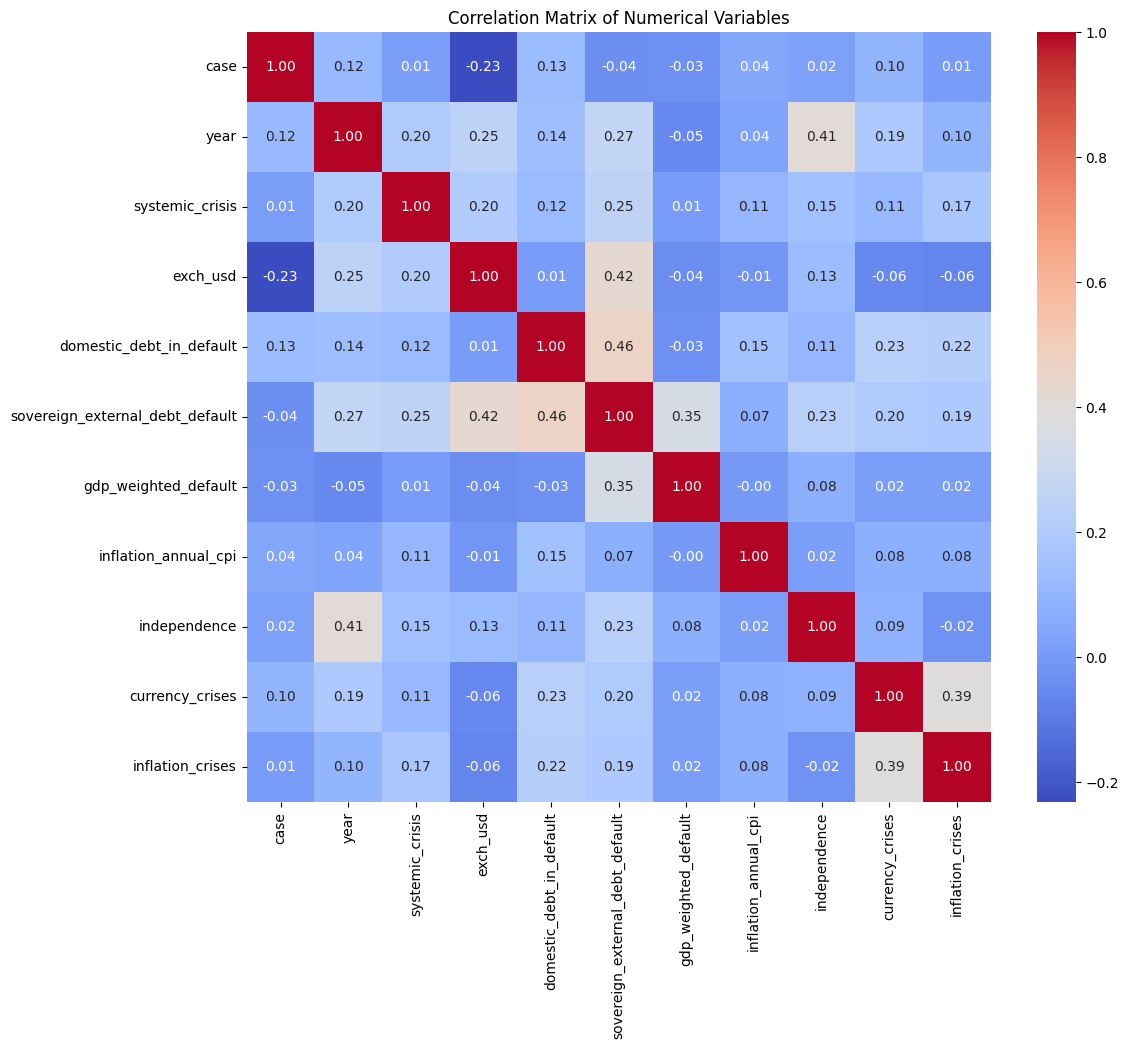

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## Key Observations (from the provided output):

systemic_crisis has a positive correlation with exch_usd (0.20), sovereign_external_debt_default (0.25), inflation_annual_cpi (0.11), independence (0.15), currency_crises (0.11), and inflation_crises (0.17). This indicates that as these variables tend to increase, the likelihood of a systemic crisis also tends to increase.
sovereign_external_debt_default shows a relatively strong positive correlation with domestic_debt_in_default (0.46) and exch_usd (0.42).
year also shows some positive correlations, particularly with independence (0.41), suggesting a trend over time. Also we can see that inflation crisis can be affected by currency crisis(0.39)

Positively there is no sigh of multicollinearity.

### TRAINING A LOGISSTIC REGRESSION MODEL TO PREDICT FUTURE BANKING CRISIS

First, let's define our target variable (`y`) as 'systemic_crisis' and the features (`X`) by dropping 'systemic_crisis' and other non-feature columns. We also need to handle categorical features like 'cc3', 'country', and 'banking_crisis' using one-hot encoding.

In [23]:
# Define target variable
y = data['systemic_crisis']

# Define features
X = data.drop(columns=['systemic_crisis', 'case', 'cc3', 'country'])

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, columns=['banking_crisis'], drop_first=True)

display(X.head())
display(y.head())

,year,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis_no_crisis
0,1870,0.052264,0,0,0.0,3.441456,0,0,0,False
1,1871,0.052798,0,0,0.0,14.149140,0,0,0,True
2,1872,0.052274,0,0,0.0,-3.718593,0,0,0,True
3,1873,0.051680,0,0,0.0,11.203897,0,0,0,True
4,1874,0.051308,0,0,0.0,-3.848561,0,0,0,True


,systemic_crisis
0,1
1,0
2,0
3,0
4,0


Now, I will split the data into training and testing sets. This is crucial for evaluating the model's performance on unseen data.

In [24]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (847, 10)
X_test shape: (212, 10)
y_train shape: (847,)
y_test shape: (212,)


Now, we will scale the numerical features using `StandardScaler`. Scaling is important for logistic regression to prevent features with larger values from dominating the learning process.

In [28]:
# Initialize StandardScaler
scaler = StandardScaler()

# Get numerical column names from X (excluding one-hot encoded 'banking_crisis_no_crisis')
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Scale numerical features in X_train and X_test
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

display(X_train.head())
display(X_test.head())

,year,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis_no_crisis
331,-1.857744,-0.387662,-0.207614,-0.429669,-0.14958,-0.040371,0.541415,-0.391364,-0.388349,True
44,0.170766,-0.353413,-0.207614,-0.429669,-0.14958,-0.040367,0.541415,-0.391364,-0.388349,True
307,-2.595385,-0.387654,-0.207614,-0.429669,-0.14958,-0.044466,0.541415,-0.391364,-0.388349,True
323,-2.103625,-0.387658,-0.207614,-0.429669,-0.14958,-0.041020,0.541415,-0.391364,-0.388349,True
1009,-0.136584,-0.389461,-0.207614,-0.429669,-0.14958,-0.043162,-1.847013,-0.391364,-0.388349,True


,year,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis_no_crisis
576,-0.782019,-0.384951,-0.207614,-0.429669,-0.14958,-0.031768,-1.847013,2.371011,2.575001,True
312,-2.441710,-0.387652,-0.207614,-0.429669,-0.14958,-0.049660,0.541415,-0.391364,-0.388349,True
70,0.969876,0.290028,-0.207614,-0.429669,-0.14958,-0.044125,0.541415,-0.391364,-0.388349,True
682,0.601056,-0.341181,-0.207614,2.327373,-0.14958,-0.029269,0.541415,2.371011,-0.388349,True
896,1.400167,-0.372664,-0.207614,-0.429669,-0.14958,-0.042100,0.541415,-0.391364,-0.388349,True


Now that the data is prepared and scaled, let's train a Logistic Regression model.

In [29]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


The Logistic Regression model has been trained. Now, let's make predictions on the test set and evaluate the model's performance.

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.9858
Precision: 0.8889
Recall: 0.9412
F1-Score: 0.9143
ROC AUC Score: 0.9967
Confusion Matrix:
 [[193   2]
 [  1  16]]


The model achieved an accuracy of 98.58%, indicating that it correctly classified the vast majority of observations. However, given the class imbalance, this high accuracy is largely influenced by the dominance of non-crisis cases.

True Negatives (193): Correctly identified non-crisis years
True Positives (16): Correctly identified crisis years
False Positives (2): Non-crisis years incorrectly predicted as crises
False Negatives (1): Crisis year missed by the model

This indicates that the model makes very few classification errors, with only 3 misclassifications out of 212 observations.

Precision measures the proportion of predicted crises that were actually crises.

The model achieves a precision of 88.89%, meaning that when it predicts a systemic crisis, it is correct nearly 9 out of 10 times.
The presence of 2 false positives suggests a small tendency to over-predict crises.

### Recall measures the model’s ability to detect actual crises.

With a recall of 94.12%, the model successfully identifies almost all crisis events.
Only 1 crisis event was missed, which is particularly important in financial risk contexts where missing a crisis can have severe consequences.

### The F1-score balances precision and recall.

A value of 0.9143 indicates a strong trade-off between correctly identifying crises and minimizing false alarms.
This suggests that the model is well-calibrated for imbalanced classification.

The ROC AUC score evaluates the model’s ability to distinguish between crisis and non-crisis periods across all classification thresholds.

A score of 0.9967 indicates near-perfect separability between the two classes.
This implies that the model is highly effective at ranking observations by their likelihood of being a crisis.

### Key Insights
The model demonstrates excellent predictive performance, particularly in identifying systemic crises.
It achieves high recall, ensuring that very few crisis events are missed.
The very high ROC AUC suggests strong underlying relationships between predictors (e.g., inflation, debt defaults, currency crises) and systemic crises.
The slightly lower precision indicates a minor trade-off, where the model occasionally flags non-crisis periods as crises.

#### Conclusion

Overall, the logistic regression model is highly reliable for predicting systemic financial crises in the African context. Its ability to accurately detect crisis events while maintaining a low error rate makes it a valuable tool for early warning systems and financial stability analysis.